# Visualización Consolidada: Evaluación y Resultados Finales
Este notebook combina los resultados de la evaluación inicial con los resultados finales, añadiendo una barra adicional para los pipelines finales con header.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid")

# Configurar fuente Palatino
plt.rcParams['font.family'] = 'serif'

### 1. Carga de Datos - Evaluación Inicial
Cargamos los resultados de `evaluations_result/`.

In [2]:
eval_dir_initial = Path("evaluations_result")
all_data_initial = []

for doc_type in ["images", "pdfs"]:
    type_dir = eval_dir_initial / doc_type
    if not type_dir.exists():
        continue
    for method_dir in type_dir.iterdir():
        if method_dir.is_dir():
            csv_path = method_dir / "results.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df['Metodo'] = method_dir.name
                df['Tipo Documento'] = doc_type
                all_data_initial.append(df)

if all_data_initial:
    df_initial = pd.concat(all_data_initial, ignore_index=True)

    # Mapeo para convertir el nombre de la carpeta al nombre que usamos en la gráfica
    name_mapping_initial = {
        'docling': 'Docling',
        'docling_header': 'Docling + header',
        'mineru': 'MinerU',
        'mineru_header': 'MinerU + header',
        'pymupdf': 'PyMuPDF4LLM',
        'pymupdf_header': 'PyMuPDF4LLM + header',
        'pymupdf_text': 'PyMuPDF',
        'pymupdf_text_header': 'PyMuPDF + header'
    }
    
    # Aplicar el mapeo a la columna Metodo
    df_initial['Metodo'] = df_initial['Metodo'].map(name_mapping_initial).fillna(df_initial['Metodo'])
    # Limpiar errores: Convertir "Error" a NaN y asegurar que la columna es numérica
    df_initial['Puntuación'] = pd.to_numeric(df_initial['Puntuación'], errors='coerce')
    df_initial = df_initial.dropna(subset=['Puntuación'])
    print(f"Cargados {len(df_initial)} registros de evaluación inicial en total.")
    
    # Separar por tipo de documento
    df_initial_images = df_initial[df_initial['Tipo Documento'] == 'images'].copy()
    df_initial_pdfs = df_initial[df_initial['Tipo Documento'] == 'pdfs'].copy()
    
    # Limpiar nombre de archivo: quitar extensión para mostrar solo el stem
    df_initial_images['Archivo'] = df_initial_images['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    df_initial_pdfs['Archivo'] = df_initial_pdfs['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    
    mean_scores_initial_images = df_initial_images.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    mean_scores_initial_pdfs = df_initial_pdfs.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
else:
    print("No se encontraron resultados iniciales.")
    df_initial_images = pd.DataFrame()
    df_initial_pdfs = pd.DataFrame()
    mean_scores_initial_images = pd.DataFrame()
    mean_scores_initial_pdfs = pd.DataFrame()

Cargados 785 registros de evaluación inicial en total.


### 2. Carga de Datos - Resultados Finales
Cargamos los resultados de `final_evaluations/`.

In [3]:
eval_dir_final = Path("final_evaluations")
all_data_final = []

for doc_type in ["images", "pdfs"]:
    type_dir = eval_dir_final / doc_type
    if not type_dir.exists():
        continue
    for method_dir in type_dir.iterdir():
        if method_dir.is_dir():
            csv_path = method_dir / "results.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df['Metodo'] = method_dir.name
                df['Tipo Documento'] = doc_type
                all_data_final.append(df)

if all_data_final:
    df_final = pd.concat(all_data_final, ignore_index=True)

    # Mapeo para convertir el nombre de la carpeta al nombre que usamos en la gráfica
    name_mapping_final = {
        'docling': 'Docling',
        'docling_header': 'Docling + header',
        'mineru': 'MinerU',
        'mineru_header': 'MinerU + header',
        'pymupdf': 'PyMuPDF4LLM',
        'pymupdf_header': 'PyMuPDF4LLM + header',
        'pymupdf_text': 'PyMuPDF',
        'pymupdf_text_header': 'PyMuPDF + header'
    }
    
    # Aplicar el mapeo a la columna Metodo
    df_final['Metodo'] = df_final['Metodo'].map(name_mapping_final).fillna(df_final['Metodo'])
    # Limpiar errores: Convertir "Error" a NaN y asegurar que la columna es numérica
    df_final['Puntuación'] = pd.to_numeric(df_final['Puntuación'], errors='coerce')
    df_final = df_final.dropna(subset=['Puntuación'])
    print(f"Cargados {len(df_final)} registros de evaluación final en total.")
    
    # Separar por tipo de documento
    df_final_images = df_final[df_final['Tipo Documento'] == 'images'].copy()
    df_final_pdfs = df_final[df_final['Tipo Documento'] == 'pdfs'].copy()
    
    # Limpiar nombre de archivo: quitar extensión para mostrar solo el stem
    df_final_images['Archivo'] = df_final_images['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    df_final_pdfs['Archivo'] = df_final_pdfs['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    
    mean_scores_final_images = df_final_images.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    mean_scores_final_pdfs = df_final_pdfs.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
else:
    print("No se encontraron resultados finales.")
    df_final_images = pd.DataFrame()
    df_final_pdfs = pd.DataFrame()
    mean_scores_final_images = pd.DataFrame()
    mean_scores_final_pdfs = pd.DataFrame()

Cargados 111 registros de evaluación final en total.


### 3. Combinar Resultados para Visualización
Añadimos los resultados finales como nuevas filas con nombres específicos.

In [4]:
# Filtrar solo los métodos finales que queremos añadir
if not mean_scores_final_images.empty:
    # Para imágenes: "Pipeline final (MinerU + header)"
    final_images_mineru = mean_scores_final_images[mean_scores_final_images['Metodo'] == 'MinerU + header'].copy()
    if not final_images_mineru.empty:
        final_images_mineru['Metodo'] = 'Pipeline final (MinerU + header)'
        mean_scores_initial_images = pd.concat([mean_scores_initial_images, final_images_mineru], ignore_index=True)

# Para PDFs: "Pipeline final (PyMuPDF + header)"
if not mean_scores_final_pdfs.empty:
    final_pdfs_pymupdf = mean_scores_final_pdfs[mean_scores_final_pdfs['Metodo'] == 'PyMuPDF + header'].copy()
    if not final_pdfs_pymupdf.empty:
        final_pdfs_pymupdf['Metodo'] = 'Pipeline final (PyMuPDF + header)'
        mean_scores_initial_pdfs = pd.concat([mean_scores_initial_pdfs, final_pdfs_pymupdf], ignore_index=True)

# Definir colores para todos los métodos incluyendo los nuevos
method_colors = {
    'Docling': '#4A90D9',
    'Docling + header': '#2C5F8E',
    'MinerU': '#63F89C',
    'MinerU + header': '#09C852',
    'PyMuPDF4LLM': '#F8D563',
    'PyMuPDF4LLM + header': '#F4BD0B',
    'PyMuPDF': '#FF745C',
    'PyMuPDF + header': '#D11F00',
    'Pipeline final (MinerU + header)': '#800080',  # Morado
    'Pipeline final (PyMuPDF + header)': '#800080'   # Morado
}

### 4. Imágenes - Puntuación Media por Método

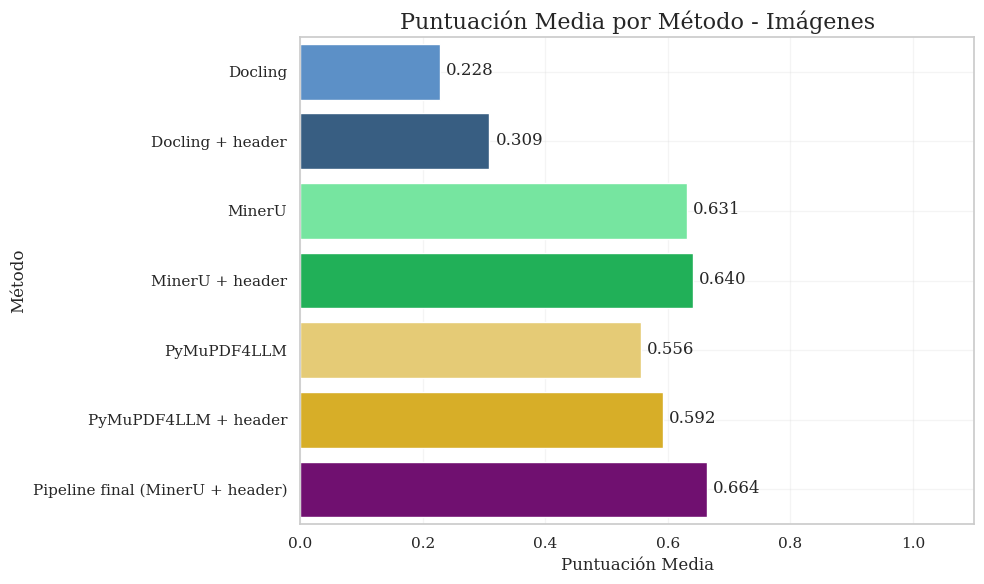

In [5]:
if not mean_scores_initial_images.empty:
    plt.figure(figsize=(10, 6))
    
    # Ordenar los métodos para que los nuevos aparezcan al final
    order = ['Docling', 'Docling + header', 'MinerU', 'MinerU + header', 
             'PyMuPDF4LLM', 'PyMuPDF4LLM + header', 'PyMuPDF', 'PyMuPDF + header',
             'Pipeline final (MinerU + header)']
    
    # Filtrar solo los métodos que están en los datos
    available_methods = [m for m in order if m in mean_scores_initial_images['Metodo'].values]
    mean_scores_plot = mean_scores_initial_images[mean_scores_initial_images['Metodo'].isin(available_methods)]
    
    colors = [method_colors[m] for m in available_methods]
    
    ax = sns.barplot(data=mean_scores_plot, x='Puntuación', y='Metodo', hue='Metodo', 
                     palette=colors, dodge=False, legend=False, order=available_methods)
    plt.title('Puntuación Media por Método - Imágenes', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        idx = int(p.get_y())
        method_name = available_methods[idx]
        
        if method_name.startswith('Pipeline final'):
            label_x = width / 2
            label_y = p.get_y() + p.get_height()/2.
            parts = method_name.split('(')
            if len(parts) == 2:
                label_text = 'Pipeline final\n(' + parts[1]
            else:
                label_text = method_name
            plt.text(label_x, label_y, label_text, ha="center", va="center", fontsize=9)
        else:
            plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.savefig('graficas/barras_imagenes_completo.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos de imágenes para visualizar.")

### 5. Imágenes - Distribución de Puntuaciones (Boxplot)

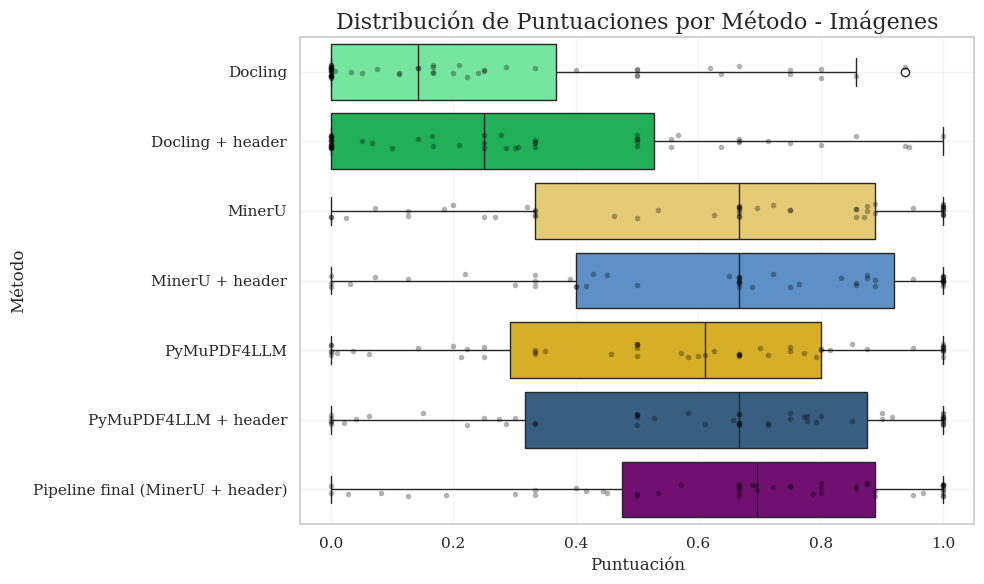

In [6]:
# Combinar datos individuales para boxplot
if not df_initial_images.empty or not df_final_images.empty:
    df_images_combined = pd.DataFrame()
    
    if not df_initial_images.empty:
        df_images_combined = pd.concat([df_images_combined, df_initial_images], ignore_index=True)
    
    if not df_final_images.empty:
        df_final_mineru = df_final_images[df_final_images['Metodo'] == 'MinerU + header'].copy()
        if not df_final_mineru.empty:
            df_final_mineru['Metodo'] = 'Pipeline final (MinerU + header)'
            df_images_combined = pd.concat([df_images_combined, df_final_mineru], ignore_index=True)
    
    if not df_images_combined.empty:
        plt.figure(figsize=(10, 6))
        
        order = ['Docling', 'Docling + header', 'MinerU', 'MinerU + header', 
                 'PyMuPDF4LLM', 'PyMuPDF4LLM + header', 'PyMuPDF', 'PyMuPDF + header',
                 'Pipeline final (MinerU + header)']
        
        available_methods = [m for m in order if m in df_images_combined['Metodo'].values]
        df_plot = df_images_combined[df_images_combined['Metodo'].isin(available_methods)]
        
        colors = [method_colors[m] for m in available_methods]
        
        sns.boxplot(data=df_plot, x='Puntuación', y='Metodo', hue='Metodo', 
                    palette=colors, dodge=False, legend=False, order=available_methods)
        sns.stripplot(data=df_plot, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
        
        plt.grid(axis='both', alpha=0.2)
        
        plt.title('Distribución de Puntuaciones por Método - Imágenes', fontsize=16)
        plt.xlabel('Puntuación', fontsize=12)
        plt.ylabel('Método', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de imágenes para visualizar.")
else:
    print("No hay datos de imágenes para visualizar.")

### 6. PDFs (Texto Seleccionable) - Puntuación Media por Método

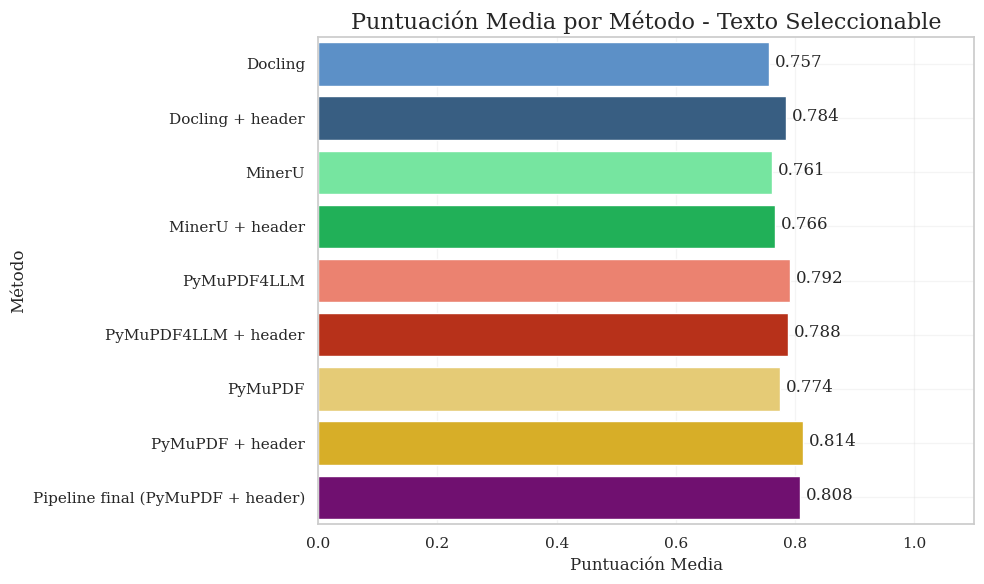

In [7]:
if not mean_scores_initial_pdfs.empty:
    plt.figure(figsize=(10, 6))
    
    # Ordenar los métodos para que los nuevos aparezcan al final
    order = ['Docling', 'Docling + header', 'MinerU', 'MinerU + header', 
             'PyMuPDF4LLM', 'PyMuPDF4LLM + header', 'PyMuPDF', 'PyMuPDF + header',
             'Pipeline final (PyMuPDF + header)']
    
    # Filtrar solo los métodos que están en los datos
    available_methods = [m for m in order if m in mean_scores_initial_pdfs['Metodo'].values]
    mean_scores_plot = mean_scores_initial_pdfs[mean_scores_initial_pdfs['Metodo'].isin(available_methods)]
    
    colors = [method_colors[m] for m in available_methods]
    
    ax = sns.barplot(data=mean_scores_plot, x='Puntuación', y='Metodo', hue='Metodo', 
                     palette=colors, dodge=False, legend=False, order=available_methods)
    plt.title('Puntuación Media por Método - Texto Seleccionable', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        idx = int(p.get_y())
        method_name = available_methods[idx]
        
        if method_name.startswith('Pipeline final'):
            label_x = width / 2
            label_y = p.get_y() + p.get_height()/2.
            parts = method_name.split('(')
            if len(parts) == 2:
                label_text = 'Pipeline final\n(' + parts[1]
            else:
                label_text = method_name
            plt.text(label_x, label_y, label_text, ha="center", va="center", fontsize=9)
        else:
            plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.savefig('graficas/barras_pdfs_completo.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos de PDFs para visualizar.")

### 7. PDFs (Texto Seleccionable) - Distribución de Puntuaciones (Boxplot)

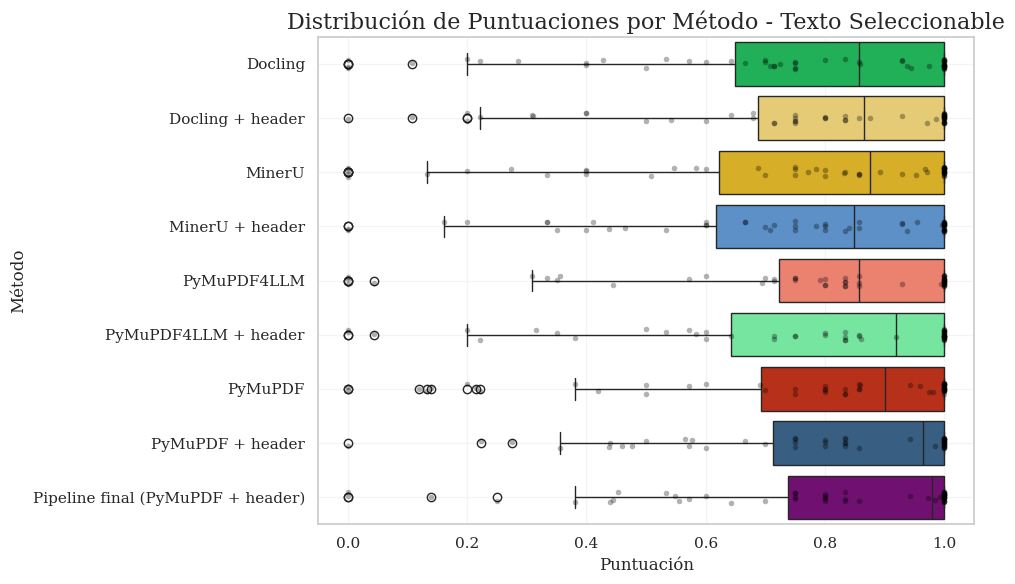

In [8]:
# Combinar datos individuales para boxplot
if not df_initial_pdfs.empty or not df_final_pdfs.empty:
    df_pdfs_combined = pd.DataFrame()
    
    if not df_initial_pdfs.empty:
        df_pdfs_combined = pd.concat([df_pdfs_combined, df_initial_pdfs], ignore_index=True)
    
    if not df_final_pdfs.empty:
        df_final_pymupdf = df_final_pdfs[df_final_pdfs['Metodo'] == 'PyMuPDF + header'].copy()
        if not df_final_pymupdf.empty:
            df_final_pymupdf['Metodo'] = 'Pipeline final (PyMuPDF + header)'
            df_pdfs_combined = pd.concat([df_pdfs_combined, df_final_pymupdf], ignore_index=True)
    
    if not df_pdfs_combined.empty:
        plt.figure(figsize=(10, 6))
        
        order = ['Docling', 'Docling + header', 'MinerU', 'MinerU + header', 
                 'PyMuPDF4LLM', 'PyMuPDF4LLM + header', 'PyMuPDF', 'PyMuPDF + header',
                 'Pipeline final (PyMuPDF + header)']
        
        available_methods = [m for m in order if m in df_pdfs_combined['Metodo'].values]
        df_plot = df_pdfs_combined[df_pdfs_combined['Metodo'].isin(available_methods)]
        
        colors = [method_colors[m] for m in available_methods]
        
        sns.boxplot(data=df_plot, x='Puntuación', y='Metodo', hue='Metodo', 
                    palette=colors, dodge=False, legend=False, order=available_methods)
        sns.stripplot(data=df_plot, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
        
        plt.grid(axis='both', alpha=0.2)
        
        plt.title('Distribución de Puntuaciones por Método - Texto Seleccionable', fontsize=16)
        plt.xlabel('Puntuación', fontsize=12)
        plt.ylabel('Método', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de PDFs para visualizar.")
else:
    print("No hay datos de PDFs para visualizar.")